# ⚙️ Notebook 03 — Sliding Window + Feature Engineering

**Input:** `data/synthetic/helmet_imu_raw.csv`  
**Output:** `data/processed/features.csv` — one row per window, 50+ features  

---

## Why Sliding Windows?

Raw IMU gives 6 numbers per timestep. That's hard to classify directly.  
Instead, we take a **window of 20 timesteps** and compute statistics over it:

```
[t0...t19]  →  mean_ax, std_ax, max_az, jerk_mean, tilt_angle, ...  →  label
[t10...t29] →  mean_ax, std_ax, ...                                  →  label
[t20...t39] →  ...                                                    →  label
```

This converts time-series → tabular ML problem.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.feature_engineering import apply_sliding_window, split_dataset, WINDOW_SIZE, STRIDE

df = pd.read_csv('../data/synthetic/helmet_imu_raw.csv')
print(f'Raw shape: {df.shape}')

Raw shape: (50000, 10)


In [2]:
# ── Apply sliding window + extract features ──────────────────────
print(f'Window size: {WINDOW_SIZE}, Stride: {STRIDE}')
print('Extracting features...\n')

feature_df = apply_sliding_window(df, window_size=WINDOW_SIZE, stride=STRIDE, verbose=True)

# Save
os.makedirs('../data/processed', exist_ok=True)
feature_df.to_csv('../data/processed/features.csv', index=False)

print(f'\nFeature matrix shape: {feature_df.shape}')
display(feature_df.head(3))

Window size: 20, Stride: 10
Extracting features...

Windows extracted  : 4500
Features per window: 70

Window label distribution:
  Normal           3592
  Pothole           297
  SuddenBrake       305
  Crash             306

Feature matrix shape: (4500, 72)


,ax_mean,ax_std,ax_max,ax_min,ax_range,ax_var,ax_rms,ax_iqr,ax_skew,ay_mean,...,jerk_mean,jerk_max,jerk_std,tilt_mean_deg,tilt_max_deg,tilt_std_deg,corr_ax_ay,corr_ax_az,label,session_id
0,-0.00476,0.256842,0.3668,-0.5853,0.9521,0.065968,0.256886,0.458050,-0.426511,0.062295,...,0.505718,0.879622,0.185986,1.787590,4.440949,0.952965,-0.262813,-0.027013,0,0
1,0.05451,0.217228,0.5304,-0.2877,0.8181,0.047188,0.223963,0.296975,0.375577,0.021875,...,0.434104,0.667902,0.166501,1.463308,3.199747,0.809159,-0.318054,0.121399,0,0
2,0.02232,0.266941,0.6385,-0.3555,0.9940,0.071258,0.267873,0.349400,0.683478,0.000575,...,0.537574,0.962353,0.223786,1.803646,3.763721,0.973227,-0.113761,-0.261017,0,0


In [3]:
# ── List all features ────────────────────────────────────────────
feature_cols = [c for c in feature_df.columns if c not in ('label', 'session_id')]
print(f'Total features: {len(feature_cols)}')
print('\nFeature groups:')
groups = {}
for f in feature_cols:
    prefix = f.split('_')[0] if '_' in f else 'other'
    groups.setdefault(prefix, []).append(f)
for grp, feats in groups.items():
    print(f'  {grp:>12}: {feats}')

Total features: 70

Feature groups:
            ax: ['ax_mean', 'ax_std', 'ax_max', 'ax_min', 'ax_range', 'ax_var', 'ax_rms', 'ax_iqr', 'ax_skew']
            ay: ['ay_mean', 'ay_std', 'ay_max', 'ay_min', 'ay_range', 'ay_var', 'ay_rms', 'ay_iqr', 'ay_skew']
            az: ['az_mean', 'az_std', 'az_max', 'az_min', 'az_range', 'az_var', 'az_rms', 'az_iqr', 'az_skew']
            gx: ['gx_mean', 'gx_std', 'gx_max', 'gx_min', 'gx_range', 'gx_var', 'gx_rms', 'gx_iqr', 'gx_skew']
            gy: ['gy_mean', 'gy_std', 'gy_max', 'gy_min', 'gy_range', 'gy_var', 'gy_rms', 'gy_iqr', 'gy_skew']
            gz: ['gz_mean', 'gz_std', 'gz_max', 'gz_min', 'gz_range', 'gz_var', 'gz_rms', 'gz_iqr', 'gz_skew']
         accel: ['accel_mag_mean', 'accel_mag_std', 'accel_mag_max']
          gyro: ['gyro_mag_mean', 'gyro_mag_std', 'gyro_mag_max']
           sma: ['sma_accel', 'sma_gyro']
          jerk: ['jerk_mean', 'jerk_max', 'jerk_std']
          tilt: ['tilt_mean_deg', 'tilt_max_deg', 'tilt_std_deg']
 

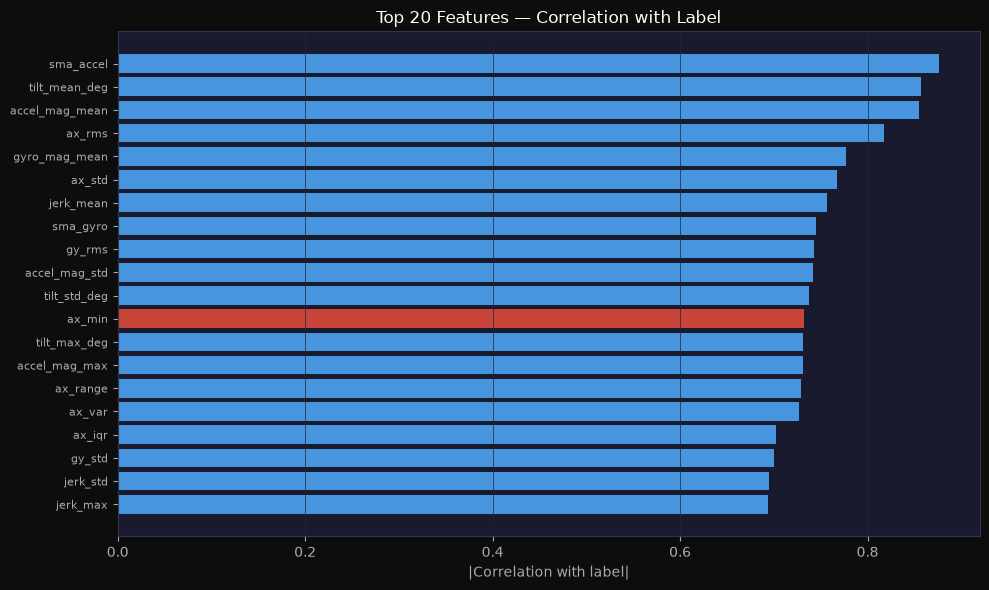


Top predictive features:
sma_accel         0.876184
tilt_mean_deg     0.856984
accel_mag_mean    0.855366
ax_rms            0.817683
gyro_mag_mean     0.777286
ax_std            0.767536
jerk_mean         0.756273
sma_gyro          0.745523
gy_rms            0.743047
accel_mag_std     0.741372
Name: label, dtype: float64


In [4]:
# ── Feature correlation with label ───────────────────────────────
corr_with_label = feature_df[feature_cols + ['label']].corr()['label'].drop('label')
top20 = corr_with_label.abs().nlargest(20)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#1a1a2e')

colors = ['#e74c3c' if corr_with_label[f] < 0 else '#4facfe' for f in top20.index]
ax.barh(range(len(top20)), top20.values[::-1], color=colors[::-1], alpha=0.85)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index[::-1], color='#e0e0e0', fontsize=8)
ax.set_xlabel('|Correlation with label|', color='#aaaaaa')
ax.set_title('Top 20 Features — Correlation with Label', color='white', fontsize=12)
ax.tick_params(colors='#aaaaaa')
ax.grid(True, axis='x', color='#222244', linewidth=0.5)
for spine in ax.spines.values(): spine.set_edgecolor('#333355')

plt.tight_layout()
plt.show()
print('\nTop predictive features:')
print(corr_with_label.abs().nlargest(10))

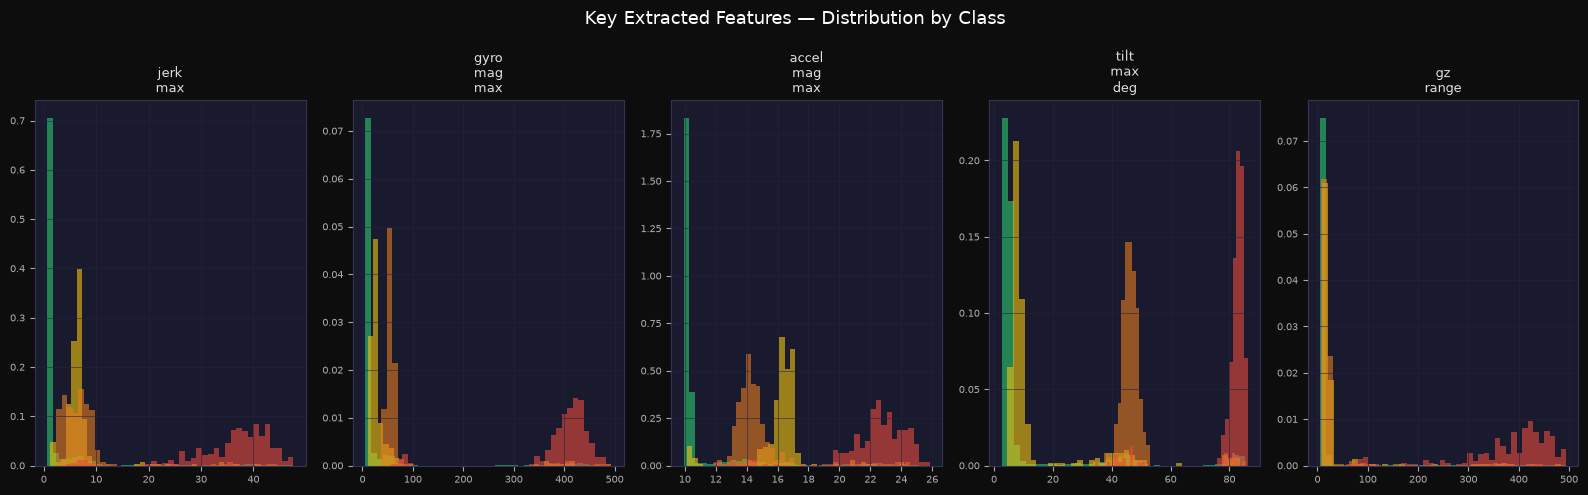

In [5]:
# ── Feature distributions — key features by class ────────────────
key_features = ['jerk_max', 'gyro_mag_max', 'accel_mag_max', 'tilt_max_deg', 'gz_range']
COLORS = {0: '#2ecc71', 1: '#f1c40f', 2: '#e67e22', 3: '#e74c3c'}
NAMES  = {0: 'Normal', 1: 'Pothole', 2: 'SuddenBrake', 3: 'Crash'}

fig, axes = plt.subplots(1, len(key_features), figsize=(16, 5))
fig.patch.set_facecolor('#0d0d0d')

for i, feat in enumerate(key_features):
    ax = axes[i]
    ax.set_facecolor('#1a1a2e')
    for lbl in range(4):
        data = feature_df[feature_df['label'] == lbl][feat]
        ax.hist(data, bins=40, alpha=0.6, color=COLORS[lbl], density=True)
    ax.set_title(feat.replace('_', '\n'), color='#e0e0e0', fontsize=9)
    ax.tick_params(colors='#aaaaaa', labelsize=7)
    ax.grid(True, color='#222244', linewidth=0.4)
    for spine in ax.spines.values(): spine.set_edgecolor('#333355')

fig.suptitle('Key Extracted Features — Distribution by Class', color='white', fontsize=13)
plt.tight_layout()
plt.show()

In [6]:
# ── Train/Test Split (session-aware, no data leakage) ────────────
X_train, X_test, y_train, y_test = split_dataset(feature_df, test_size=0.2, seed=42)

print('Train/Test split (session-aware, GroupShuffleSplit):')
print(f'  X_train: {X_train.shape}   y_train: {y_train.shape}')
print(f'  X_test : {X_test.shape}    y_test : {y_test.shape}')
print(f'\nTrain label distribution:')
print(y_train.value_counts().sort_index().rename(NAMES))
print(f'\nTest label distribution:')
print(y_test.value_counts().sort_index().rename(NAMES))

Train/Test split (session-aware, GroupShuffleSplit):
  X_train: (3600, 70)   y_train: (3600,)
  X_test : (900, 70)    y_test : (900,)

Train label distribution:
label
Normal         2851
Pothole         248
SuddenBrake     256
Crash           245
Name: count, dtype: int64

Test label distribution:
label
Normal         741
Pothole         49
SuddenBrake     49
Crash           61
Name: count, dtype: int64


In [7]:
print('\n✅ Feature engineering complete.')
print('   Saved to: data/processed/features.csv')
print(f'   {X_train.shape[1]} features per window')
print('\n   Next: notebooks/04_train_model.ipynb')


✅ Feature engineering complete.
   Saved to: data/processed/features.csv
   70 features per window

   Next: notebooks/04_train_model.ipynb
